# Day 3-2: CNN 모델 구축 및 MNIST 학습

---

## 라이브러리 불러오기

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import numpy as np
import matplotlib.pyplot as plt

# GPU 사용 가능 여부 확인
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"사용 디바이스: {device}")

사용 디바이스: cuda


---

## 1.1 MNIST 데이터셋

**MNIST**는 손글씨 숫자 이미지 데이터셋입니다.
- 훈련 데이터: 60,000개
- 테스트 데이터: 10,000개
- 이미지 크기: 28×28 픽셀 (흑백)
- 클래스: 0~9 (10개)

### 데이터 전처리
1. **ToTensor()**: PIL 이미지 → Tensor
2. **Normalize()**: 픽셀 값을 평균 0, 표준편차 1로 정규화

In [ ]:
# 데이터 전처리 정의
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))  # MNIST 평균과 표준편차
])

# 데이터셋 다운로드 및 로드
train_dataset = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
test_dataset = datasets.MNIST(root='./data', train=False, download=True, transform=transform)

# DataLoader 생성
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=1000, shuffle=False)

print(f"훈련 데이터: {len(train_dataset)}개")
print(f"테스트 데이터: {len(test_dataset)}개")

100%|██████████| 9.91M/9.91M [00:00<00:00, 16.3MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 505kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.54MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 8.76MB/s]

훈련 데이터: 60000개
테스트 데이터: 10000개


배치 이미지 shape: torch.Size([64, 1, 28, 28])
배치 레이블 shape: torch.Size([64])


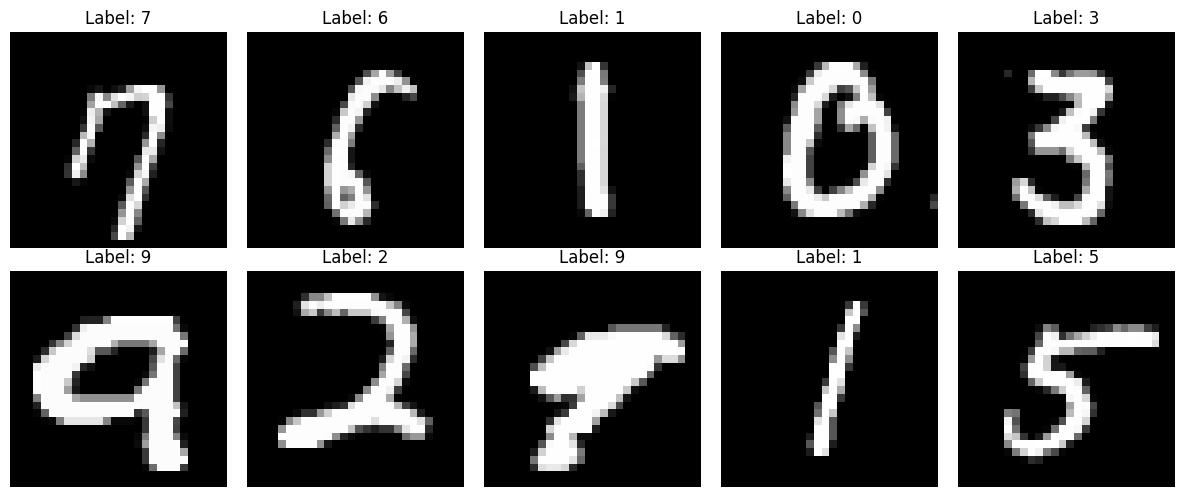

In [ ]:
# 데이터 샘플 확인
examples = iter(train_loader)
batch_images, batch_labels = next(examples)

print(f"배치 이미지 shape: {batch_images.shape}")  # [batch, channel, height, width]
print(f"배치 레이블 shape: {batch_labels.shape}")

# 이미지 시각화
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for i in range(10):
    ax = axes[i//5, i%5]
    ax.imshow(batch_images[i].squeeze(), cmap='gray')
    ax.set_title(f'Label: {batch_labels[i].item()}')
    ax.axis('off')
plt.tight_layout()
plt.show()

---

## 2.1 간단한 CNN 모델 설계

**모델 구조:**
```
Input (1, 28, 28)
    ↓
Conv2d(1→16, 3x3, padding=1) → ReLU → MaxPool(2x2)
    ↓ (16, 14, 14)
Conv2d(16→32, 3x3, padding=1) → ReLU → MaxPool(2x2)
    ↓ (32, 7, 7)
Flatten → FC(32×7×7 → 128) → ReLU → FC(128 → 10)
    ↓
Output (10 classes)
```

In [ ]:
class SimpleCNN(nn.Module):
    def __init__(self):
        super(SimpleCNN, self).__init__()

        # Convolutional layers
        self.conv1 = nn.Conv2d(1, 16, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(16, 32, kernel_size=3, padding=1)
        self.pool = nn.MaxPool2d(2, 2)

        # Fully connected layers
        self.fc1 = nn.Linear(32 * 7 * 7, 128)
        self.fc2 = nn.Linear(128, 10)

    def forward(self, x):
        # Conv Block 1
        x = self.pool(F.relu(self.conv1(x)))  # (1,28,28) → (16,14,14)

        # Conv Block 2
        x = self.pool(F.relu(self.conv2(x)))  # (16,14,14) → (32,7,7)

        # Flatten
        x = x.view(-1, 32 * 7 * 7)  # (32,7,7) → (1568,)

        # Fully Connected
        x = F.relu(self.fc1(x))
        x = self.fc2(x)

        return x

# 모델 생성
model = SimpleCNN().to(device)
print(model)
print(f"\n총 파라미터 수: {sum(p.numel() for p in model.parameters()):,}")

SimpleCNN(
  (conv1): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc1): Linear(in_features=1568, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=10, bias=True)
)

총 파라미터 수: 206,922


### ✏️ 실습 2-1: 모델 출력 확인

랜덤 입력을 넣어서 각 레이어의 출력 크기를 확인해보세요.

In [ ]:
# 테스트 입력 생성
test_input = torch.randn(1, 1, 28, 28).to(device)

with torch.no_grad():
    # Conv1
    x = F.relu(model.conv1(test_input))
    print(f"Conv1 출력: {x.shape}")
    x = model.pool(x)
    print(f"Pool1 출력: {x.shape}")

    # Conv2
    x = F.relu(model.conv2(x))
    print(f"Conv2 출력: {x.shape}")
    x = model.pool(x)
    print(f"Pool2 출력: {x.shape}")

    # Flatten
    x = x.view(-1, 32 * 7 * 7)
    print(f"Flatten 출력: {x.shape}")

    # FC
    x = F.relu(model.fc1(x))
    print(f"FC1 출력: {x.shape}")
    x = model.fc2(x)
    print(f"FC2 출력 (최종): {x.shape}")

Conv1 출력: torch.Size([1, 16, 28, 28])
Pool1 출력: torch.Size([1, 16, 14, 14])
Conv2 출력: torch.Size([1, 32, 14, 14])
Pool2 출력: torch.Size([1, 32, 7, 7])
Flatten 출력: torch.Size([1, 1568])
FC1 출력: torch.Size([1, 128])
FC2 출력 (최종): torch.Size([1, 10])


---

## 3.1 손실 함수와 옵티마이저

### CrossEntropyLoss
- 다중 클래스 분류에 사용
- Softmax + NLL Loss를 합친 것
- 모델 출력은 logits (확률이 아님)

### Adam Optimizer
- 적응적 학습률 조정
- 일반적으로 SGD보다 빠른 수렴

In [ ]:
# 손실 함수와 옵티마이저 정의
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

print(f"손실 함수: {criterion}")
print(f"옵티마이저: {optimizer}")

손실 함수: CrossEntropyLoss()
옵티마이저: Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.001
    maximize: False
    weight_decay: 0
)


## 3.2 학습 함수

에포크마다 반복할 학습 과정을 함수로 정의합니다.

In [ ]:
def train_one_epoch(model, train_loader, criterion, optimizer, device):
    model.train()  # 학습 모드
    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        outputs = model(images)

        loss = criterion(outputs, labels)

        optimizer.zero_grad()

        loss.backward()

        optimizer.step()

        # 통계
        running_loss += loss.item()
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    epoch_loss = running_loss / len(train_loader)
    epoch_acc = 100 * correct / total

    return epoch_loss, epoch_acc

## 3.3 평가 함수

테스트 데이터로 모델 성능을 평가합니다.

In [ ]:
def evaluate(model, test_loader, criterion, device):
    model.eval()  # 평가 모드
    running_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            running_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    test_loss = running_loss / len(test_loader)
    test_acc = 100 * correct / total

    return test_loss, test_acc

### ✏️ 실습 3-1: 학습 루프 완성하기

전체 학습 과정을 구현해보세요.

In [ ]:
# 학습 기록
num_epochs = 5
train_losses = []
train_accs = []
test_losses = []
test_accs = []

for epoch in range(num_epochs):
    # 학습
    train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)

    # 평가
    test_loss, test_acc = evaluate(model, test_loader, criterion, device)

    # 기록
    train_losses.append(train_loss)
    train_accs.append(train_acc)
    test_losses.append(test_loss)
    test_accs.append(test_acc)

    print(f"Epoch [{epoch+1}/{num_epochs}]")
    print(f"  Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.2f}%")
    print(f"  Test Loss: {test_loss:.4f}, Test Acc: {test_acc:.2f}%")

Epoch [1/5]
  Train Loss: 0.1614, Train Acc: 95.04%
  Test Loss: 0.0595, Test Acc: 98.05%
Epoch [2/5]
  Train Loss: 0.0493, Train Acc: 98.41%
  Test Loss: 0.0428, Test Acc: 98.55%
Epoch [3/5]
  Train Loss: 0.0343, Train Acc: 98.92%
  Test Loss: 0.0584, Test Acc: 98.10%
Epoch [4/5]
  Train Loss: 0.0260, Train Acc: 99.18%
  Test Loss: 0.0408, Test Acc: 98.73%
Epoch [5/5]
  Train Loss: 0.0197, Train Acc: 99.38%
  Test Loss: 0.0278, Test Acc: 99.16%


---

## 4.1 학습 곡선 그리기

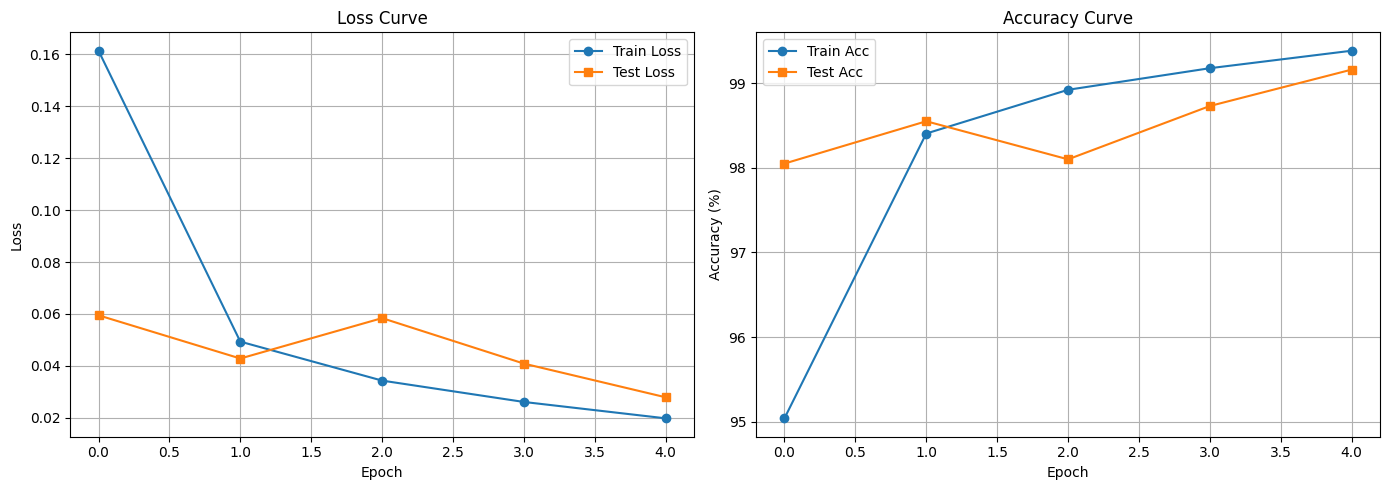

In [ ]:
# 학습 곡선 시각화
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Loss
ax1.plot(train_losses, label='Train Loss', marker='o')
ax1.plot(test_losses, label='Test Loss', marker='s')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.set_title('Loss Curve')
ax1.legend()
ax1.grid(True)

# Accuracy
ax2.plot(train_accs, label='Train Acc', marker='o')
ax2.plot(test_accs, label='Test Acc', marker='s')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy (%)')
ax2.set_title('Accuracy Curve')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()

## 4.2 예측 결과 확인

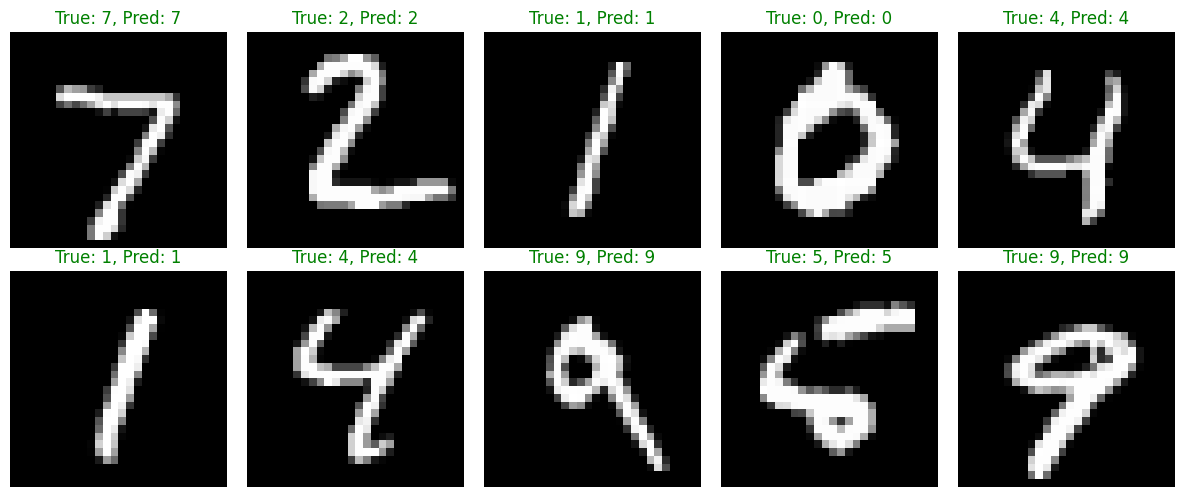

In [ ]:
# 테스트 데이터에서 일부 샘플 예측
model.eval()
test_iter = iter(test_loader)
test_images, test_labels = next(test_iter)
test_images = test_images.to(device)

with torch.no_grad():
    outputs = model(test_images)
    _, predicted = torch.max(outputs, 1)

# 시각화
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for i in range(10):
    ax = axes[i//5, i%5]
    img = test_images[i].cpu().squeeze()
    ax.imshow(img, cmap='gray')

    true_label = test_labels[i].item()
    pred_label = predicted[i].item()

    color = 'green' if true_label == pred_label else 'red'
    ax.set_title(f'True: {true_label}, Pred: {pred_label}', color=color)
    ax.axis('off')

plt.tight_layout()
plt.show()

---

## 5.1 Data Augmentation이란?

학습 데이터를 **인위적으로 변형**하여 데이터셋을 확장하는 기법입니다.

### 왜 필요할까요?

**문제 상황:**
- 실제 데이터는 다양한 변형이 존재 (회전, 이동, 밝기 변화 등)
- 학습 데이터가 제한적이면 모델이 과적합되기 쉬움
- 테스트 데이터의 작은 변화에도 성능 저하

**해결책: Data Augmentation**
- 기존 이미지를 변형하여 더 많은 학습 데이터 생성
- 모델이 다양한 상황에 강건해짐 (Robustness 향상)
- 과적합 방지 효과

### 📚 주요 Augmentation 기법

| 기법 | 설명 | 효과 |
|------|------|------|
| **RandomRotation** | 이미지를 무작위로 회전 | 회전된 객체 인식 능력 향상 |
| **RandomHorizontalFlip** | 좌우 반전 | 좌우 대칭 변화에 강건 |
| **RandomAffine** | 이동, 회전, 크기 조정 | 위치/크기 변화에 강건 |
| **RandomCrop** | 무작위로 자르기 | 객체의 일부만 보이는 상황 대응 |
| **ColorJitter** | 밝기, 대비, 채도 조정 | 조명 변화에 강건 |


![이미지 설명](https://i0.wp.com/ubiai.tools/wp-content/uploads/2023/11/0_LNtz0G4cngapDH41.png?fit=960%2C540&ssl=1)


---

100%|██████████| 26.4M/26.4M [00:02<00:00, 12.9MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 202kB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 3.82MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 25.2MB/s]


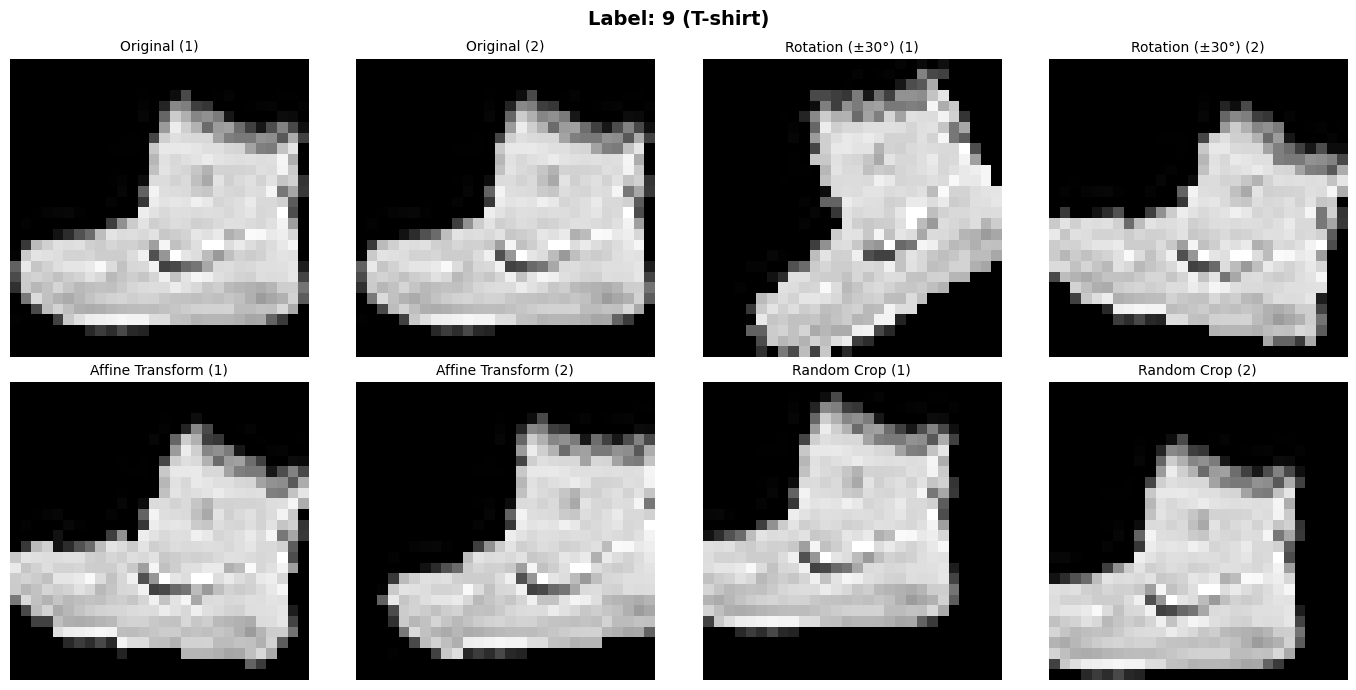

✅ 같은 이미지도 다양하게 변형될 수 있습니다!
   → 모델이 더 일반화된 특징을 학습할 수 있습니다.


In [ ]:
# 📖 Data Augmentation 시각화
import matplotlib.pyplot as plt
from torchvision import datasets, transforms
from PIL import Image

# Fashion-MNIST 하나의 이미지 로드
dataset = datasets.FashionMNIST(root='./data', train=True, download=True)
original_img, label = dataset[0]

# 다양한 Augmentation 정의
augmentations = {
    'Original': transforms.ToTensor(),
    'Rotation (±30°)': transforms.Compose([
        transforms.RandomRotation(30),
        transforms.ToTensor()
    ]),
    'Affine Transform': transforms.Compose([
        transforms.RandomAffine(degrees=15, translate=(0.1, 0.1)),
        transforms.ToTensor()
    ]),
    'Random Crop': transforms.Compose([
        transforms.Pad(4),
        transforms.RandomCrop(28),
        transforms.ToTensor()
    ]),
}

# 시각화
fig, axes = plt.subplots(2, 4, figsize=(14, 7))
axes = axes.flatten()

for idx, (name, transform) in enumerate(augmentations.items()):
    # 2개씩 보여주기 (원본 + 변형)
    for i in range(2):
        img_tensor = transform(original_img)
        axes[idx * 2 + i].imshow(img_tensor.squeeze(), cmap='gray')
        if i == 0:
            axes[idx * 2 + i].set_title(f'{name} (1)', fontsize=10)
        else:
            axes[idx * 2 + i].set_title(f'{name} (2)', fontsize=10)
        axes[idx * 2 + i].axis('off')

plt.suptitle(f'Label: {label} (T-shirt)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("✅ 같은 이미지도 다양하게 변형될 수 있습니다!")
print("   → 모델이 더 일반화된 특징을 학습할 수 있습니다.")


### ✏️ 실습 5-1: Augmentation으로 학습하기

증강된 데이터로 모델을 다시 학습해보세요.

In [ ]:
# 새 모델 생성
model_aug = SimpleCNN().to(device)
criterion_aug = nn.CrossEntropyLoss()
optimizer_aug = optim.Adam(model_aug.parameters(), lr=0.001)

# 학습 (3 에포크만)
num_epochs_aug = 3
test_accs_aug = []

for epoch in range(num_epochs_aug):
    # 증강된 데이터로 학습
    train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)

    # 원본 테스트 데이터로 평가
    test_loss, test_acc = evaluate(model, test_loader, criterion, device)
    test_accs_aug.append(test_acc)

    print(f"Epoch [{epoch+1}/{num_epochs_aug}]")
    print(f"  Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.2f}%")
    print(f"  Test Acc: {test_acc:.2f}%")

print(f"\n최종 테스트 정확도 (Augmentation): {test_accs_aug[-1]:.2f}%")
print(f"최종 테스트 정확도 (Original): {test_accs[2]:.2f}%")  # 3번째 epoch

Epoch [1/3]
  Train Loss: 0.0159, Train Acc: 99.45%
  Test Acc: 99.03%
Epoch [2/3]
  Train Loss: 0.0127, Train Acc: 99.58%
  Test Acc: 99.03%
Epoch [3/3]
  Train Loss: 0.0100, Train Acc: 99.68%
  Test Acc: 99.14%

최종 테스트 정확도 (Augmentation): 99.14%
최종 테스트 정확도 (Original): 98.10%


---

## 6. 종합 실습: 더 깊은 CNN 모델

3개의 Convolutional Block을 가진 더 깊은 모델을 만들어봅시다.

**구조:**
```
Conv2d(1→32, 3x3) → ReLU → Conv2d(32→32, 3x3) → ReLU → MaxPool(2x2)
Conv2d(32→64, 3x3) → ReLU → Conv2d(64→64, 3x3) → ReLU → MaxPool(2x2)
Conv2d(64→128, 3x3) → ReLU → MaxPool(2x2)
Flatten → FC(128×3×3 → 256) → ReLU → Dropout(0.5) → FC(256 → 10)
```

In [ ]:
class DeepCNN(nn.Module):
    def __init__(self):
        super(DeepCNN, self).__init__()

        # Block 1
        self.conv1_1 = nn.Conv2d(1, 32, kernel_size=3, padding=1)
        self.conv1_2 = nn.Conv2d(32, 32, kernel_size=3, padding=1)

        # Block 2
        self.conv2_1 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.conv2_2 = nn.Conv2d(64, 64, kernel_size=3, padding=1)

        # Block 3
        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, padding=1)

        self.pool = nn.MaxPool2d(2, 2)

        # FC layers
        self.fc1 = nn.Linear(128 * 3 * 3, 256)
        self.fc2 = nn.Linear(256, 10)
        self.dropout = nn.Dropout(0.5)

    def forward(self, x):
        # Block 1: 28x28 → 14x14
        x = F.relu(self.conv1_1(x))
        x = F.relu(self.conv1_2(x))
        x = self.pool(x)

        # Block 2: 14x14 → 7x7
        x = F.relu(self.conv2_1(x))
        x = F.relu(self.conv2_2(x))
        x = self.pool(x)

        # Block 3: 7x7 → 3x3
        x = F.relu(self.conv3(x))
        x = self.pool(x)

        # FC
        x = x.view(-1, 128 * 3 * 3)
        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)

        return x

# 모델 생성 및 학습
deep_model = DeepCNN().to(device)
print(f"총 파라미터 수: {sum(p.numel() for p in deep_model.parameters()):,}")

# 학습 설정
criterion_deep = nn.CrossEntropyLoss()
optimizer_deep = optim.Adam(deep_model.parameters(), lr=0.001)

# 5 에포크 학습
for epoch in range(5):
    train_loss, train_acc = train_one_epoch(deep_model, train_loader,
                                             criterion_deep, optimizer_deep, device)
    test_loss, test_acc = evaluate(deep_model, test_loader, criterion_deep, device)

    print(f"Epoch [{epoch+1}/5] - Test Acc: {test_acc:.2f}%")

총 파라미터 수: 436,586
Epoch [1/5] - Test Acc: 98.70%
Epoch [2/5] - Test Acc: 99.06%
Epoch [3/5] - Test Acc: 99.13%
Epoch [4/5] - Test Acc: 99.34%
Epoch [5/5] - Test Acc: 99.19%


---

## 🎯 오늘 배운 내용

1. **MNIST 데이터셋**: 손글씨 숫자 분류
2. **CNN 모델 구축**: Conv → ReLU → Pool → FC
3. **학습 및 평가**: 학습 루프, 손실/정확도 계산
4. **Data Augmentation**: 회전, 이동 등으로 데이터 증강
5. **더 깊은 모델**: 여러 Conv Block 쌓기

### 다음 시간에는...
더 복잡한 데이터셋(CIFAR-10)과 유명한 CNN 아키텍처들을 배워봅시다!